## Plotting aligned parcellation maps across atlases

In [1]:
import os, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from py_util_dx.py_utils import setProjectPath
from py_util_dx.data_utils import get_roi_vtx_from_fs32k, get_roi_pacels, get_glasser_labels
from scipy.stats import ttest_1samp
import Functional_Fusion.atlas_map as am 
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import matplotlib as mpl 
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import nibabel as nib
from visualizations import plot_flatmap_labels
from nitools.cifti import surf_from_cifti
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import MDS
import matplotlib.colors as mcolors
from scipy.linalg import orthogonal_procrustes

In [2]:
mpl.rcParams['font.family'] = 'helvetica'   # Global font family
mpl.rcParams['font.size'] = 12              # Global font size 
full_width = 8.5
half_width = full_width/2

In [3]:
projectPath, mainResultsPath = setProjectPath()
dataset_name = 'MDTB' # or Demand
surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
resultsPath = os.path.join(mainResultsPath, 'START_A3_bayes_parcellation', f'{dataset_name}')

In [4]:
parcellations_of_interests = ['glasser', 'schaefer100']
Vs = []
n_parcels = [] 
roi = 'PFC' 
parcel_names = []

for parcellation in parcellations_of_interests:
    PKL_bayes_parcellation = os.path.join(resultsPath, parcellation, f'output_{roi}.pkl')
    with open(PKL_bayes_parcellation, 'rb') as pf:
        output = pickle.load(pf)
        V = output['V']
        Vs.append(V)
        n_parcels.append(V.shape[1])
        parcel_names.append(output['parcel_names_in_group']) 

In [5]:
Vs = np.hstack(Vs) 

In [6]:
Vs.shape 

(29, 76)

In [7]:
n_parcels

[44, 32]

In [8]:
D = 1 - cosine_similarity(Vs.T)
D.shape 

(76, 76)

In [9]:
mds = MDS(
    n_components=2,
    dissimilarity='precomputed',
    random_state=0,
    n_init=10,
    max_iter=300
)

X_joint = mds.fit_transform(D)  # (76, 2)

In [10]:
X_glasser = X_joint[:n_parcels[0]]
X_schaefer100 = X_joint[n_parcels[0]:] 

In [11]:
def embedding_to_rgb_hsv(X, S_max=0.85, V=0.9):
    x, y = X[:, 0], X[:, 1]

    hue = (np.arctan2(y, x) + np.pi) / (2 * np.pi)
    radius = np.sqrt(x**2 + y**2)

    saturation = np.clip(radius * S_max, 0, S_max)

    hsv = np.column_stack([hue, saturation, np.full(len(X), V)])
    rgb = mcolors.hsv_to_rgb(hsv)
    return rgb

In [12]:
color_rgb_glasser = embedding_to_rgb_hsv(X_glasser)
color_rgb_schaefer100 = embedding_to_rgb_hsv(X_schaefer100) 

In [13]:
color_rgb_glasser.shape 

(44, 3)

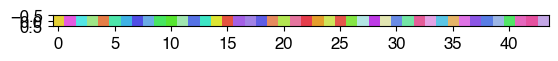

In [14]:
plt.imshow(color_rgb_glasser[np.newaxis, :]) 

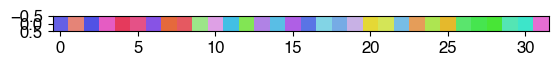

In [15]:
plt.imshow(color_rgb_schaefer100[np.newaxis, :]) 

In [16]:
color_df_glasser = pd.DataFrame(data=color_rgb_glasser, index=parcel_names[0], columns=['r', 'g', 'b']) 
color_df_glasser

,r,g,b
55b,0.900000,0.819708,0.213642
SFL,0.900000,0.360512,0.882091
a24,0.329098,0.900000,0.899387
d32,0.621672,0.900000,0.529572
8BM,0.900000,0.490636,0.280585
p32,0.303919,0.900000,0.666892
10r,0.248721,0.700721,0.900000
47m,0.315719,0.308028,0.900000
8Av,0.418452,0.675707,0.900000
8Ad,0.280263,0.900000,0.383490


In [17]:
temp_df = pd.read_csv(os.path.join(surface_helpers_dir, f'atl-glasser.lut'), sep=' ', header=None)  
temp_df = temp_df.rename(columns={0:'indx', 1:'r', 2:'g', 3:'b', 4:'roi'})
temp_df

,indx,r,g,b,roi
0,1,0.0000,0.2000,0.4000,L_V1_ROI
1,2,0.2118,0.4039,0.5059,L_MST_ROI
2,3,0.2431,0.3059,0.6980,L_V6_ROI
3,4,0.0000,0.2980,0.6000,L_V2_ROI
4,5,0.0000,0.4000,0.8000,L_V3_ROI
...,...,...,...,...,...
355,176,0.1922,0.1569,0.1373,R_STSva_ROI
356,177,0.3216,0.2118,0.2314,R_TE1m_ROI
357,178,0.5059,0.2314,0.2431,R_PI_ROI
358,179,0.5961,0.3176,0.4275,R_a32pr_ROI


In [18]:
temp_df.index = temp_df['roi'].str.lstrip('LR_').str.rstrip('_ROI') 
temp_df

,indx,r,g,b,roi
roi,,,,,
V1,1,0.0000,0.2000,0.4000,L_V1_ROI
MST,2,0.2118,0.4039,0.5059,L_MST_ROI
V6,3,0.2431,0.3059,0.6980,L_V6_ROI
V2,4,0.0000,0.2980,0.6000,L_V2_ROI
V3,5,0.0000,0.4000,0.8000,L_V3_ROI
...,...,...,...,...,...
STSva,176,0.1922,0.1569,0.1373,R_STSva_ROI
TE1m,177,0.3216,0.2118,0.2314,R_TE1m_ROI
P,178,0.5059,0.2314,0.2431,R_PI_ROI


In [19]:
temp_df.update(color_df_glasser)
temp_df

,indx,r,g,b,roi
roi,,,,,
V1,1,0.000000,0.200000,0.400000,L_V1_ROI
MST,2,0.211800,0.403900,0.505900,L_MST_ROI
V6,3,0.243100,0.305900,0.698000,L_V6_ROI
V2,4,0.000000,0.298000,0.600000,L_V2_ROI
V3,5,0.000000,0.400000,0.800000,L_V3_ROI
...,...,...,...,...,...
STSva,176,0.192200,0.156900,0.137300,R_STSva_ROI
TE1m,177,0.321600,0.211800,0.231400,R_TE1m_ROI
P,178,0.505900,0.231400,0.243100,R_PI_ROI


In [20]:
temp_df.to_csv(os.path.join(surface_helpers_dir, f'atl-glasser.lut'), sep=' ', index=False, header=False)

In [21]:
# names = pd.read_csv(os.path.join(surface_helpers_dir, f'atl-schaefer100.lut'), header=None, skiprows=lambda x: x % 2 == 1)  
# names = names.rename(columns={0:'roi'})
# names 

In [22]:
# colors = pd.read_csv(os.path.join(surface_helpers_dir, f'atl-schaefer100.lut'), header=None, skiprows=lambda x: x % 2 == 0, sep=' ')
# colors

In [23]:
# temp_df = pd.merge(colors[[0, 1, 2, 3]], names, left_index=True, right_index=True) 
# temp_df

In [24]:
# temp_df = temp_df.rename(columns={0: 'indx', 1: 'r', 2: 'g', 3: 'b'}) 
# temp_df

In [25]:
# temp_df[['r', 'g', 'b']] /= 255 
# temp_df 

In [26]:
# temp_df = temp_df.set_index('indx') 
# temp_df

In [ ]:
temp_df = pd.read_csv(os.path.join(surface_helpers_dir, f'atl-schaefer100.lut'), sep='\s+', header=None, names=['indx', 'r', 'g', 'b', 'roi'])
temp_df 

In [ ]:
temp_df = temp_df.set_index('indx') 
temp_df 

In [ ]:
temp_df[0:20]

In [ ]:
color_df_schaefer100 = pd.DataFrame(data=color_rgb_schaefer100, index=list(map(int, parcel_names[1])), columns=['r', 'g', 'b']) 
color_df_schaefer100.index.name = 'indx' 
color_df_schaefer100

In [ ]:
temp_df.update(color_df_schaefer100)
temp_df[0:20]

In [ ]:
color_df_schaefer100.index 

In [ ]:
temp_df.index 

In [34]:
temp_df.to_csv(os.path.join(surface_helpers_dir, f'atl-schaefer100.lut'), sep=' ', index=True, header=False) 

In [27]:
# getting the mds solutions for individuals 
Vs_indv = [] 

for parcellation in parcellations_of_interests:
    PKL_Vs = os.path.join(mainResultsPath, 'START_A4_parcellation_evaluation', dataset_name, parcellation, f'output_{roi}_cv.pkl')
    with open(PKL_Vs, 'rb') as pf:
        output_indv = pickle.load(pf)
        Vs_indv.append(output_indv['Vs'])

Vs_indv = np.concatenate(Vs_indv, axis=-1) 
Vs_indv.shape 

(24, 32, 76)

In [28]:
n_subjects = Vs_indv.shape[0]

In [29]:
Ds = [] 
for subjI in np.arange(n_subjects):
    Ds.append(1 - cosine_similarity(Vs_indv[subjI].T))

Ds = np.array(Ds) 
Ds[0].shape 

(76, 76)

In [30]:
X_indiv = [mds.fit_transform(D) for D in Ds] 
X_indiv = np.array(X_indiv) 
X_indiv.shape 

(24, 76, 2)

In [ ]:
X_indiv_glasser = X_indiv[:, :n_parcels[0]]
X_indiv_schaefer100 = X_indiv[:, n_parcels[0]:] 
X_indiv_glasser.shape 

In [40]:
for subjI in np.arange(n_subjects):
    R, _ = orthogonal_procrustes(X_indiv_glasser[subjI], X_glasser)
    X_indiv_glasser[subjI] = X_indiv_glasser[subjI] @ R 

    R, _ = orthogonal_procrustes(X_indiv_schaefer100[subjI], X_schaefer100)
    X_indiv_schaefer100[subjI] = X_indiv_schaefer100[subjI] @ R 

In [41]:
color_rgb_glasser_indiv = [embedding_to_rgb_hsv(y) for y in X_indiv_glasser] 
color_rgb_schaefer100_indiv = [embedding_to_rgb_hsv(y) for y in X_indiv_schaefer100] 

In [ ]:
# generating color for each subject for the individualized glass atlas
temp_df = pd.read_csv(os.path.join(surface_helpers_dir, f'atl-glasser.lut'), sep=' ', header=None)  
temp_df = temp_df.rename(columns={0:'indx', 1:'r', 2:'g', 3:'b', 4:'roi'})
temp_df.index = temp_df['roi'].str.lstrip('LR_').str.rstrip('_ROI') 
temp_df

In [43]:
for subjI in np.arange(n_subjects):
    color_df = pd.DataFrame(data=color_rgb_glasser_indiv[subjI], index=parcel_names[0], columns=['r', 'g', 'b']) 
    temp_df.update(color_df)
    temp_df.to_csv(os.path.join(surface_helpers_dir, f'atl-glasser-aligned_subj{subjI}.lut'), sep=' ', index=False, header=False) 

In [ ]:
# generating color for each subject for the individualized schaefer100 atlas
temp_df = pd.read_csv(os.path.join(surface_helpers_dir, f'atl-schaefer100.lut'), sep='\s+', header=None, names=['indx', 'r', 'g', 'b', 'roi'])
temp_df = temp_df.set_index('indx') 
temp_df 

In [45]:
for subjI in np.arange(n_subjects):
    color_df = pd.DataFrame(data=color_rgb_schaefer100_indiv[subjI], index=list(map(int, parcel_names[1])), columns=['r', 'g', 'b']) 
    color_df.index.name = 'indx' 
    temp_df.update(color_df)
    temp_df.to_csv(os.path.join(surface_helpers_dir, f'atl-schaefer100-aligned_subj{subjI}.lut'), sep=' ', index=True, header=False) 

In [52]:
# atlas_name = 'glasser'
atlas_name = 'schaefer100'
# atlas_name = 'yeo17'
surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
resultsPath = os.path.join(mainResultsPath, 'START_A4_parcellation_evaluation', f'{dataset_name}', atlas_name, 'aligned_atlas')
if not os.path.exists(resultsPath):
    os.makedirs(resultsPath)

In [53]:
example_subjIs = np.arange(n_subjects)
n_example_subjects = len(example_subjIs) 
frames_dict = {
    'PFC': [[-210, 25, -90, 140], [0, 240, -110, 120]], 
    'visual': [[100, 230, -70, 160], [-250, -50, -70, 130]], 
    'somatosensory':[[-10, 80, -10, 160], [-60, 30, -10, 140]], 
    'parietal': [[20, 140, 0, 160], [-140, -30, 0, 160]]
}
gridspec_dict = {
    'PFC': [-0.2, -0.05],
    'visual': [-0.2, -0.12],
    'parietal': [-0.55, -0.25],
    'somatosensory': [-0.55, -0.05]
}

In [54]:
atlas_str = 'fs32k'
atlas, ainf = am.get_atlas(atlas_str)

In [55]:
PKL_individualized_parcellation = os.path.join(projectPath, 'results', 'START_A3_bayes_parcellation', f'{dataset_name}', atlas_name, f'output_{roi}.pkl')
with open(PKL_individualized_parcellation, 'rb') as pf:
    output_indiv = pickle.load(pf)
    labels_in_group = output_indiv['labels_in_group']
    parcel_names_in_group = output_indiv['parcel_names_in_group']

    U_individual = output_indiv['U_individual']     # data only parcellation
    indiv_parcellation = output_indiv['indiv_parcellation']

    U_group = output_indiv['U_group']
    group_parcellation = output_indiv['group_parcellation']

    group_parcellation[group_parcellation==0] = np.max(group_parcellation)

In [ ]:
# plotting the group map
# fig, ax = plt.subplots(1, 2, figsize=(full_width, 8), constrained_layout=True, gridspec_kw={'wspace': gridspec_dict[roi][0], 'hspace': gridspec_dict[roi][1]})
fig, ax = plt.subplots(1, 2, figsize=(full_width, 8), constrained_layout=True)
fig.set_figwidth(full_width)

[label_L, label_R] = surf_from_cifti(atlas.data_to_cifti(group_parcellation.reshape(1, -1)))
plt.axes(ax[0])
plot_flatmap_labels(label_L, 'L', frame=frames_dict[roi][0], borders=None, atlas=atlas_name)

plt.axes(ax[1])
plot_flatmap_labels(label_R, 'R', frame=frames_dict[roi][1], borders=None, atlas=atlas_name)

plt.suptitle(f'group {atlas_name}, {roi}')
plt.tight_layout() 

JPG_fig = os.path.join(resultsPath, f'group_{atlas_name}_{roi}.jpg')
plt.savefig(JPG_fig, dpi=500, format='jpg')

In [ ]:
for subjI in example_subjIs:
    fig, ax = plt.subplots(1, 2, figsize=(full_width, 8), constrained_layout=True, gridspec_kw={'wspace': gridspec_dict[roi][0], 'hspace': gridspec_dict[roi][1]})
    fig.set_figwidth(full_width)
    
    [label_L, label_R] = surf_from_cifti(atlas.data_to_cifti(indiv_parcellation[subjI].reshape(1, -1)))
    plt.axes(ax[0])
    plot_flatmap_labels(label_L, 'L', frame=frames_dict[roi][0], borders=None, atlas=atlas_name, lut=os.path.join(surface_helpers_dir, f'atl-{atlas_name}-aligned_subj{subjI}.lut'))
    
    plt.axes(ax[1])
    plot_flatmap_labels(label_R, 'R', frame=frames_dict[roi][1], borders=None, atlas=atlas_name, lut=os.path.join(surface_helpers_dir, f'atl-{atlas_name}-aligned_subj{subjI}.lut'))

    plt.suptitle(f'subject {subjI}, {roi}')
    plt.tight_layout() 

    JPG_fig = os.path.join(resultsPath, f'example_{atlas_name}_{roi}_subject_{subjI}.jpg')
    plt.savefig(JPG_fig, dpi=500, format='jpg')